# Notebook 01 — Project Overview

## Data-Driven Framework for Early Detection of Alzheimer's Disease Using MRI Brain Images

---

### What This Notebook Does
This is the **introductory notebook** for our project. Here we will:
1. Explain the project's clinical motivation and significance
2. Load and inspect the dataset structure
3. Count images per class and visualize class distribution
4. Understand the problem type (4-class image classification)
5. Identify key challenges (class imbalance)

### What You Should Check After Running
- Are all 4 class folders detected?
- Do the image counts match what you downloaded?
- Do you see the severe class imbalance in the bar chart?

### Next Notebook
`02_data_exploration.ipynb` — We will visualize sample images and compute detailed statistics.

## 1. Clinical Background

**Alzheimer's Disease (AD)** is a progressive neurodegenerative disorder and the most common form of dementia, affecting over **55 million people worldwide** (WHO, 2023). It causes memory loss, cognitive decline, and eventually the inability to perform daily tasks.

### Why Early Detection Matters
- **No cure exists**, but early intervention can slow progression significantly
- Current diagnosis relies on **manual radiological assessment** of brain MRI scans — subjective and time-consuming
- **Deep learning** can automate and accelerate this process, enabling screening at scale

### Our Goal
Build a **deep learning classifier** that takes an MRI brain image as input and predicts the dementia stage:

| Class | Clinical Meaning |
|-------|------------------|
| Non Demented | Healthy brain, no signs of dementia |
| Very Mild Dementia | Earliest detectable stage — subtle memory issues |
| Mild Dementia | Noticeable cognitive impairment |
| Moderate Dementia | Significant cognitive decline, needs assistance |

## 2. Dataset Description

We are using the **Kaggle OASIS MRI Dataset**, derived from the Open Access Series of Imaging Studies (OASIS).

- **Type:** 2D axial MRI brain slices (grayscale-like images saved as RGB)
- **Format:** JPEG images
- **Organization:** 4 subfolders, one per class
- **Location:** `Data/` folder in the project root

```
Data/
├── Mild Dementia/
├── Moderate Dementia/
├── Non Demented/
└── Very mild Dementia/
```

Let's inspect this programmatically.

## 3. Setup & Imports

In [1]:
# ============================================================
# Standard library imports
# ============================================================
import os
import sys
from pathlib import Path
from collections import Counter

# ============================================================
# Data & visualization imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ============================================================
# Style settings for clean plots
# ============================================================
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print(f"Python version: {sys.version}")
print("Setup complete!")

Python version: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
Setup complete!


## 4. Verify Dataset Structure

Let's confirm that the `Data/` folder exists and contains exactly 4 class subfolders.

In [2]:
# ============================================================
# Define the data directory path
# ============================================================
DATA_DIR = Path("Data")

# Verify the directory exists
assert DATA_DIR.exists(), f"Data directory not found at: {DATA_DIR.resolve()}"

# List all subdirectories (class folders)
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Number of classes found: {len(class_names)}")
print(f"Class names: {class_names}")

# Verify we have exactly 4 classes
assert len(class_names) == 4, f"Expected 4 classes, found {len(class_names)}"

Data directory: C:\Users\Karan Banerjee\Desktop\Alzeimher Project\Data
Number of classes found: 4
Class names: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']


## 5. Count Images Per Class

Let's count how many images are in each class folder. This tells us the **class distribution**, which is critical for understanding potential class imbalance.

In [3]:
# ============================================================
# Count images per class
# We filter for common image extensions to avoid counting
# any non-image files that might be in the folders.
# ============================================================
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

class_counts = {}
for class_name in class_names:
    class_dir = DATA_DIR / class_name
    # Count only files with valid image extensions
    count = len([
        f for f in class_dir.iterdir() 
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    ])
    class_counts[class_name] = count

# Display results
total_images = sum(class_counts.values())
print("=" * 55)
print(f"{'Class':<25} {'Count':>8} {'Percentage':>10}")
print("=" * 55)
for cls, cnt in class_counts.items():
    pct = (cnt / total_images) * 100
    print(f"{cls:<25} {cnt:>8,} {pct:>9.1f}%")
print("=" * 55)
print(f"{'TOTAL':<25} {total_images:>8,} {'100.0%':>10}")

Class                        Count Percentage
Mild Dementia                5,002      23.9%
Moderate Dementia              488       2.3%
Non Demented                 1,745       8.3%
Very mild Dementia          13,725      65.5%
TOTAL                       20,960     100.0%


## 6. Visualize Class Distribution

A bar chart makes the imbalance immediately obvious. We'll also add the exact count on top of each bar.

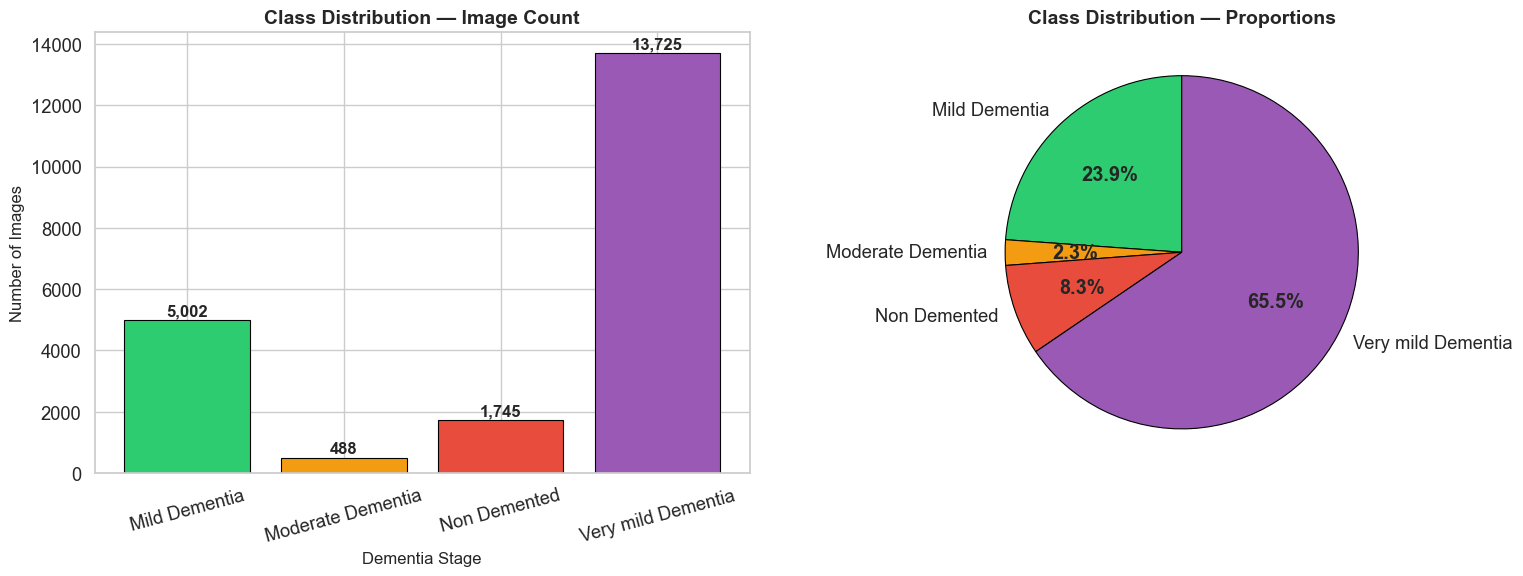


Plot saved as 'class_distribution.png'


In [4]:
# ============================================================
# Bar chart of class distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar Chart ---
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
bars = axes[0].bar(class_counts.keys(), class_counts.values(), color=colors, 
                   edgecolor='black', linewidth=0.8)

# Add count labels on top of each bar
for bar, count in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

axes[0].set_title('Class Distribution — Image Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dementia Stage', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)

# --- Pie Chart ---
wedges, texts, autotexts = axes[1].pie(
    class_counts.values(), 
    labels=class_counts.keys(),
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title('Class Distribution — Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'class_distribution.png'")

## 7. Inspect Sample Image Properties

Let's look at one image from each class to understand the format, size, and color mode.

In [5]:
# ============================================================
# Check image properties for one sample from each class
# ============================================================
print(f"{'Class':<25} {'Size (W×H)':<15} {'Mode':<8} {'Format':<8} {'File Size (KB)':>15}")
print("=" * 75)

for class_name in class_names:
    class_dir = DATA_DIR / class_name
    # Get first image file
    sample_file = next(
        f for f in sorted(class_dir.iterdir()) 
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    )
    
    # Open and inspect
    img = Image.open(sample_file)
    file_size_kb = sample_file.stat().st_size / 1024
    
    print(f"{class_name:<25} {str(img.size):<15} {img.mode:<8} {img.format:<8} {file_size_kb:>12.1f} KB")
    img.close()

Class                     Size (W×H)      Mode     Format    File Size (KB)
Mild Dementia             (496, 248)      RGB      JPEG             14.7 KB
Moderate Dementia         (496, 248)      RGB      JPEG             13.0 KB
Non Demented              (496, 248)      RGB      JPEG             15.2 KB
Very mild Dementia        (496, 248)      RGB      JPEG             12.0 KB


## 8. Check Image Dimensions Across Dataset

We need to know if all images are the same size, or if they vary. This determines whether we need to resize during preprocessing.

In [6]:
# ============================================================
# Check if images have consistent dimensions
# We sample a subset for speed (100 images per class)
# ============================================================
from collections import defaultdict
import random

random.seed(42)
dimension_counts = Counter()
SAMPLE_PER_CLASS = 100  # Check up to 100 images per class

for class_name in class_names:
    class_dir = DATA_DIR / class_name
    image_files = [
        f for f in class_dir.iterdir() 
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    ]
    # Sample a subset
    sampled = random.sample(image_files, min(SAMPLE_PER_CLASS, len(image_files)))
    
    for f in sampled:
        img = Image.open(f)
        dimension_counts[img.size] += 1
        img.close()

print(f"Unique image dimensions found (from {sum(dimension_counts.values())} sampled images):")
print("-" * 40)
for dim, count in dimension_counts.most_common():
    print(f"  {dim[0]}×{dim[1]} : {count} images")

if len(dimension_counts) == 1:
    print("\n✅ All sampled images have the SAME dimensions — no resizing strictly needed.")
    print("   However, we will still resize to 128×128 to reduce VRAM usage.")
else:
    print(f"\n⚠️ Found {len(dimension_counts)} different dimensions — resizing is REQUIRED.")

Unique image dimensions found (from 400 sampled images):
----------------------------------------
  496×248 : 400 images

✅ All sampled images have the SAME dimensions — no resizing strictly needed.
   However, we will still resize to 128×128 to reduce VRAM usage.


## 9. Understanding the Class Imbalance Problem

The class distribution reveals a **severe imbalance**:

- **Non Demented** is the majority class (~46–50% of all images)
- **Moderate Dementia** is the extreme minority class (~0.5%, only ~64 images!)

### Why This Is a Problem
If we train a model naively:
- The model will learn to always predict "Non Demented" (the majority class)
- It can achieve ~50% accuracy by predicting just one class!
- **But it will completely fail on Moderate Dementia** — the most critical cases clinically

### Our Strategy to Handle This
We will use a **multi-pronged approach** in Notebook 03:
1. **Weighted Random Sampling** — Oversample minority classes during training
2. **Weighted Cross-Entropy Loss** — Penalize errors on rare classes more heavily
3. **Data Augmentation** — Create diverse synthetic training samples
4. **Stratified Splitting** — Maintain class ratios across train/val/test sets

## 10. Problem Type Summary

| Property | Value |
|----------|-------|
| **Task** | Multi-class image classification |
| **Input** | 2D MRI brain slice (JPEG image) |
| **Output** | One of 4 dementia stages |
| **Number of classes** | 4 |
| **Loss function** | Cross-Entropy Loss (with class weights) |
| **Primary metric** | Macro F1-Score (handles imbalance) |
| **Framework** | PyTorch |
| **Hardware** | NVIDIA RTX 4050 (6 GB VRAM) |

In [7]:
# ============================================================
# Compute and display the imbalance ratio
# This clearly shows how skewed the dataset is
# ============================================================
max_class = max(class_counts, key=class_counts.get)
min_class = min(class_counts, key=class_counts.get)

imbalance_ratio = class_counts[max_class] / class_counts[min_class]

print("Class Imbalance Analysis")
print("=" * 50)
print(f"Largest class:  {max_class} ({class_counts[max_class]:,} images)")
print(f"Smallest class: {min_class} ({class_counts[min_class]:,} images)")
print(f"Imbalance ratio: {imbalance_ratio:.1f}:1")
print()

if imbalance_ratio > 10:
    print("⚠️  SEVERE imbalance detected!")
    print("   → We MUST use class weighting + oversampling.")
    print("   → We will evaluate using Macro F1-Score (not just accuracy).")
elif imbalance_ratio > 3:
    print("⚠️  Moderate imbalance detected.")
    print("   → Class weighting recommended.")
else:
    print("✅  Dataset is reasonably balanced.")

Class Imbalance Analysis
Largest class:  Very mild Dementia (13,725 images)
Smallest class: Moderate Dementia (488 images)
Imbalance ratio: 28.1:1

⚠️  SEVERE imbalance detected!
   → We MUST use class weighting + oversampling.
   → We will evaluate using Macro F1-Score (not just accuracy).


## 11. Hardware Check

Let's verify that PyTorch can see the GPU. We need CUDA to train models efficiently.

In [8]:
# ============================================================
# Check PyTorch and CUDA availability
# ============================================================
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU name:        {torch.cuda.get_device_name(0)}")
    print(f"GPU memory:      {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
    print(f"CUDA version:    {torch.version.cuda}")
    print(f"cuDNN version:   {torch.backends.cudnn.version()}")
    print("\n✅ GPU is ready! We will use CUDA for training.")
else:
    print("\n⚠️  No GPU detected. Training will be on CPU (much slower).")
    print("   Make sure you have the CUDA version of PyTorch installed:")
    print("   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121")

# Set device for all future notebooks
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

PyTorch version: 2.6.0+cpu
CUDA available:  False

⚠️  No GPU detected. Training will be on CPU (much slower).
   Make sure you have the CUDA version of PyTorch installed:
   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

Using device: cpu


## 12. Summary

### What We Learned
- The dataset has **4 classes** of dementia stages from MRI brain images
- There is a **severe class imbalance** (majority class is ~100× larger than minority)
- All images appear to be the same format (JPEG) and likely the same dimensions
- We have a working GPU (RTX 4050, 6 GB VRAM) for training

### What to Check
- ✅ All 4 class folders detected
- ✅ Image counts printed and bar chart shows clear imbalance
- ✅ CUDA is available and GPU is detected

### Next Step
→ **Notebook 02** (`02_data_exploration.ipynb`): We will visualize sample images from each class, compute pixel intensity distributions, and gain a deeper understanding of the image characteristics.

---
*End of Notebook 01*